In [344]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(
    "/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot"
)

import sage_loader
from sage_loader import get_params, load_snapshot, load_all_snapshots
from snapshot_redshift_mapper import SnapshotRedshiftMapper as z_mapper
print(sage_loader.__file__)
dir(sage_loader)

/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot/sage_loader.py


['DummyArgs',
 'SnapshotRedshiftMapper',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'get_params',
 'importlib',
 'load_all_snapshots',
 'load_snapshot',
 'os',
 'path',
 'sage_plot',
 'spec']

In [345]:
param_file = "/Users/pater32/Documents/GitHub/sage/GWRecoil/input/tng50.par"

params = get_params(param_file)
galaxies, volume, metadata = load_snapshot(param_file, 99)
data = load_all_snapshots(param_file)

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000
Input files contain: 15618 trees, 22282 galaxies.
Reading 22282 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHu

In [346]:
print(load_snapshot(param_file, 0))

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
(rec.array([],
          dtype={'names': ['SnapNum', 'Type', 'GalaxyIndex', 'CentralGalaxyIndex', 'SAGEHaloIndex', 'SAGETreeIndex', 'SimulationHaloIndex', 'mergeType', 'mergeIntoID', 'mergeIntoSnapNum', 'dT', 'Pos', 'Vel', 'Spin', 'Len', 'Mvir', 'CentralMvir', 'Rvir', 'Vvir', 'Vmax', 'VelDisp', 'ColdGas', 'StellarMass', 'BulgeMass', 'HotGas', 'EjectedMass', 'BlackHoleMass', 'IntraClusterStars', 'NSC', 'MetalsColdGas', 'MetalsStellarMass', 'MetalsBulgeMass', 'MetalsHotGas', 'MetalsEjectedMass', 'MetalsIntraClusterStars', 'SfrDisk', 'SfrBulge', 'SfrDiskZ', 'SfrBulgeZ', 'DiskRadius', 'Co

(5.0, 9.0)

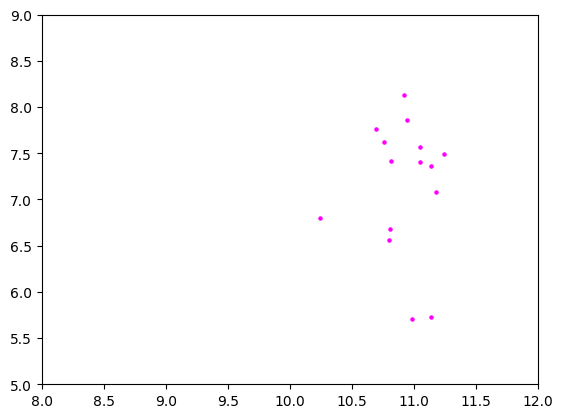

In [347]:
## RECREATE STELLARMASS - BHMASS PLOT 

w = (galaxies.StellarMass > 0) & (galaxies.BlackHoleMass > 0)
m = w & (galaxies.BHmergeCount > 0)
r = w & (galaxies.BHrefillCount > 0) & (galaxies.BHejectFlag == 0)

hubble_h = metadata['hubble_h']

stellar_mass = np.log10(galaxies.StellarMass[w] * 1e10 / hubble_h)
bh_mass = np.log10(galaxies.BlackHoleMass[w] * 1e10 / hubble_h)

stellar_mass_merge = np.log10(galaxies.StellarMass[m] * 1e10 / hubble_h)
bh_mass_merge = np.log10(galaxies.BlackHoleMass[m] * 1e10 / hubble_h)

stellar_mass_refill = np.log10(galaxies.StellarMass[r] * 1e10 / hubble_h)
bh_mass_refill = np.log10(galaxies.BlackHoleMass[r] * 1e10 / hubble_h)


# plt.scatter(
#     stellar_mass,
#     bh_mass,
#     marker = 'o',
#     color = 'grey',
#     s=1,
#     alpha = 0.2
# )

# plt.scatter(
#     stellar_mass_merge,
#     bh_mass_merge,
#     marker = 'o',
#     color = 'cornflowerblue',
#     s=5
# )

plt.scatter(
    stellar_mass_refill,
    bh_mass_refill,
    marker = 'o',
    color = 'magenta',
    s=5
)

plt.xlim(8.0, 12.0)
plt.ylim(5, 9)

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000
Input files contain: 15618 trees, 22282 galaxies.
Reading 22282 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z0.000_0
[          1119     1000000000     4000000000     7000000000
  2235000000057  2241000000000  4476000000000  4520000000000
  6698000000000  6708000000000  8925000000933  8931000000000
  8936000000000  8937000000000 13387000000561 13388000000304
 13389000000000 13398000000000]
Amount of BHs ejected for galaxy 1119 : 1
Amount of BHs ejected for galaxy 2241000000000 : 1
Amount of BHs ejected for galaxy 4472000000000 : 1
Amount of BHs ejected for galaxy 4476000000000 : 1
Amount of BHs ejected for galaxy 4520000000000 : 1
Amount of BHs ejected for galaxy 6698000000000 : 1
Amount of BH

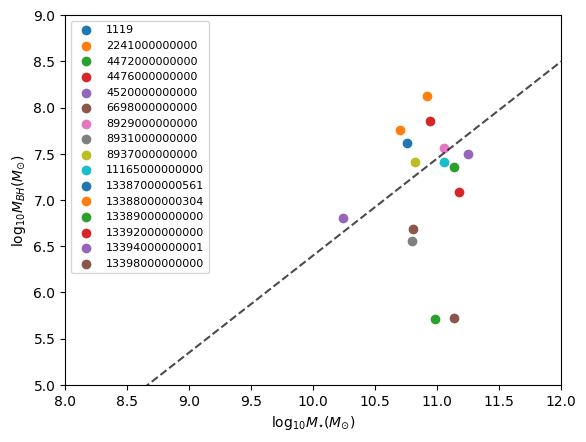

In [375]:
galaxies, volume, metadata = load_snapshot(param_file, 99)

w = (galaxies.StellarMass > 0) & (galaxies.BlackHoleMass > 0)
r = w & (galaxies.BHrefillCount > 0) & (galaxies.BHejectFlag == 0)

gal_ids_refilled = galaxies.GalaxyIndex[r]
print(gal_id_refilled)

gal_id = 1119


for i in range(len(galaxies)):
    for gal_id in gal_ids_refilled:
        if galaxies.GalaxyIndex[i] == gal_id:
            stellar_mass = np.log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
            bh_mass = np.log10(galaxies.BlackHoleMass[i] * 1e10 / hubble_h)
            plt.scatter(stellar_mass, bh_mass, marker='o', label = gal_id)
            print('Amount of BHs ejected for galaxy', gal_id,':', galaxies.BHejectCount[i])
x_hr_r = np.logspace(8, 12, 100)
y_hr_r = 10 ** (7.45) * (x_hr_r / 1.0e11) ** 1.05
plt.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
plt.legend(fontsize=8)
plt.xlabel(r'log$_{10}M_{\star}(M_{\odot})$')
plt.ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
plt.xlim(8.0, 12.0)
plt.ylim(5, 9)
plt.show()


In [ ]:
for snap in range(0, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies)

    for i in range(array_length):
        for gal_id in gal_ids_refilled:
            if (galaxies.BHEjectedTime[i] > 0) & (galaxies.GalaxyIndex[i] == gal_id):
                redshift = metadata['redshift']
                hubble_h = metadata['hubble_h']
                print('BH for galaxy', gal_id, 'was ejected at redshift:', redshift)

BH for galaxy 2241000000000 was ejected at redshift: 4.1800000013468
BH for galaxy 13392000000000 was ejected at redshift: 4.0100000101202005
BH for galaxy 1119 was ejected at redshift: 3.0099999936241
BH for galaxy 8929000000000 was ejected at redshift: 2.7299999964565003
BH for galaxy 13387000000561 was ejected at redshift: 2.5799999992124003
BH for galaxy 4520000000000 was ejected at redshift: 2.4400000049535997
BH for galaxy 13388000000304 was ejected at redshift: 2.3200000030543997
BH for galaxy 11165000000000 was ejected at redshift: 2.10000000155
BH for galaxy 13394000000001 was ejected at redshift: 2.10000000155
BH for galaxy 6698000000000 was ejected at redshift: 1.90000000174
BH for galaxy 13389000000000 was ejected at redshift: 1.90000000174
BH for galaxy 8931000000000 was ejected at redshift: 1.6700000014685004
BH for galaxy 4476000000000 was ejected at redshift: 1.5999999974000003
BH for galaxy 8937000000000 was ejected at redshift: 1.5999999974000003
BH for galaxy 4472000

In [383]:
## CHECK THAT MERGE AND REFILL OVERLAP IS THE SAME LENGTH AS REFILL

refill_count = []

for i in range(len(stellar_mass_refill)):
    for j in range(len(stellar_mass_merge)):
        if stellar_mass_refill[i] == stellar_mass_merge[j]:
            refill_count.append(stellar_mass_merge)

print(len(np.array(refill_count)))
print(len(stellar_mass_refill))

galaxies = load_snapshot(param_file, 0)
print(galaxies)
    

16
16
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/model_z20.050_0
(rec.array([],
          dtype={'names': ['SnapNum', 'Type', 'GalaxyIndex', 'CentralGalaxyIndex', 'SAGEHaloIndex', 'SAGETreeIndex', 'SimulationHaloIndex', 'mergeType', 'mergeIntoID', 'mergeIntoSnapNum', 'dT', 'Pos', 'Vel', 'Spin', 'Len', 'Mvir', 'CentralMvir', 'Rvir', 'Vvir', 'Vmax', 'VelDisp', 'ColdGas', 'StellarMass', 'BulgeMass', 'HotGas', 'EjectedMass', 'BlackHoleMass', 'IntraClusterStars', 'NSC', 'MetalsColdGas', 'MetalsStellarMass', 'MetalsBulgeMass', 'MetalsHotGas', 'MetalsEjectedMass', 'MetalsIntraClusterStars', 'SfrDisk', 'SfrBulge', 'SfrDiskZ', 'SfrBulgeZ', 'DiskRadius

10 7.0100000044055
14 5.5299999920987
14 5.5299999920987
17 4.660000007358001
19 4.1800000013468
19 4.1800000013468
20 4.0100000101202005
23 3.2799999965759996
24 3.0099999936241
24 3.0099999936241
26 2.7299999964565003
26 2.7299999964565003
26 2.7299999964565003
27 2.5799999992124003
27 2.5799999992124003
27 2.5799999992124003
27 2.5799999992124003
28 2.4400000049535997
28 2.4400000049535997
28 2.4400000049535997
29 2.3200000030543997
29 2.3200000030543997
30 2.209999997432
30 2.209999997432
30 2.209999997432
31 2.10000000155
31 2.10000000155
32 2.000000003
32 2.000000003
33 1.90000000174
33 1.90000000174
33 1.90000000174
33 1.90000000174
33 1.90000000174
33 1.90000000174
34 1.8200000006204
34 1.8200000006204
34 1.8200000006204
35 1.7399999973695999
35 1.7399999973695999
35 1.7399999973695999
36 1.6700000014685004
36 1.6700000014685004
36 1.6700000014685004
37 1.5999999974000003
37 1.5999999974000003
37 1.5999999974000003
37 1.5999999974000003
38 1.5299999999747
38 1.5299999999747
40 

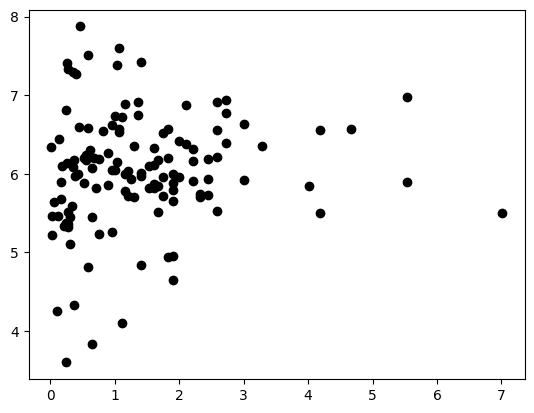

In [384]:
## ANALYZE GALAXIES WITH REFILLED BHs
    # data = snap : galaxies, volume, metadata
    # ie: data[2][0] = snapshot 2, galaxies

# w = data[10][0].BHEjectedTime > 0
# print(data[10][0].BHEjectedTime[w])


eject_times = []
stellar_masses = []
bh_masses = []
merge_types = []
for snap in range(1, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies)

    if array_length > 0:
        
        for i in range(array_length):
            if galaxies.BHEjectedTime[i] > 0:
                eject_time = galaxies.BHEjectedTime[i]
                redshift = metadata['redshift']
                tot_ejections = galaxies.BHejectCount[i]
                print(eject_time, redshift)
                
                # snap_num = snap - 1 # gal information stored in 
                # print("A BH was ejected for this snapshot:", snap_num, "At time:", eject_time)
                

                stellar_mass = np.log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
                bh_mass = np.log10(galaxies.MassofLastEjectedBH[i] * 1e10 / hubble_h)

                stellar_masses.append(stellar_mass)
                bh_masses.append(bh_mass)
                eject_times.append(redshift)



plt.scatter(eject_times, bh_masses, marker='o', color='black')



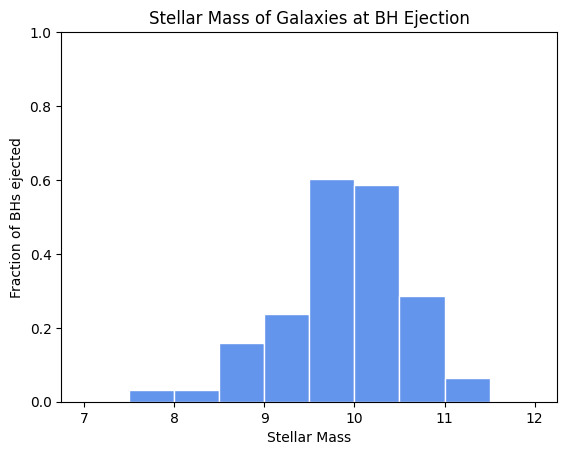

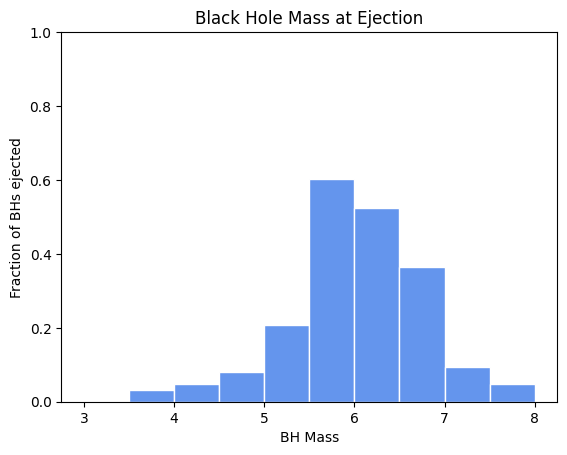

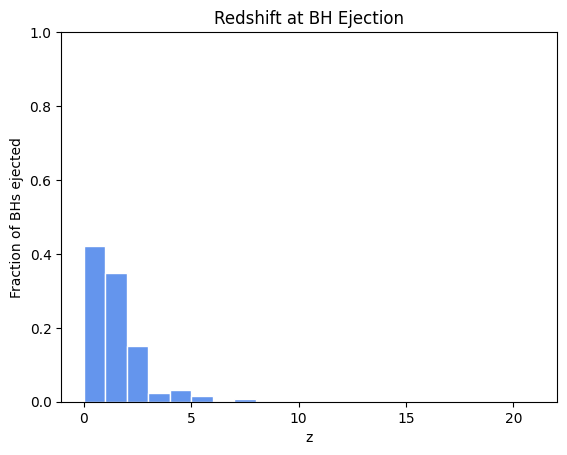

In [385]:
## MAKE HISTOGRAMS FOR GALAXIES 

# GALAXY SM HISTOGRAM (WHEN WERE THESE BLACK HOLES EJECTED)
min_sm = 7.0
max_sm = 12.0
interval = 0.5
n_bins = int((max_sm-min_sm)/interval)
hist, edges_sm = np.histogram(stellar_mass, range = (min_sm, max_sm), bins = n_bins)
plt.hist(stellar_masses, bins=edges_sm, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Stellar Mass of Galaxies at BH Ejection')
plt.ylim(0, 1)
plt.show()

# BLACK HOLE MASS AT EJECTION 
min_bh = 3.0
max_bh = 8.0
interval = 0.5
n_bins = int((max_bh-min_bh)/interval)
hist, edges_bh = np.histogram(bh_mass, range = (min_bh, max_bh), bins = n_bins)
plt.hist(bh_masses, bins=edges_bh, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('BH Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Black Hole Mass at Ejection')
plt.ylim(0, 1)
plt.show()

min_z = 0
max_z = 21.0
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges_z = np.histogram(eject_times, range = (min_z, max_z), bins = n_bins)
plt.hist(eject_times, bins=edges_z, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('z')
plt.ylabel('Fraction of BHs ejected')
plt.title('Redshift at BH Ejection')
plt.ylim(0, 1)
plt.show()

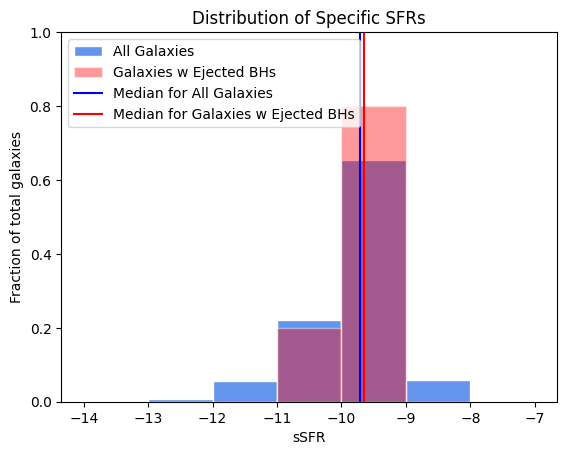

2561
-9.706913
15
-9.648231
13
-9.602279


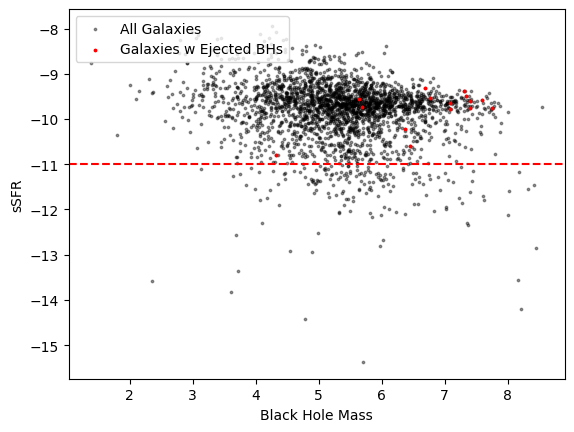

In [386]:
## STELLAR POPULATIONS OF ALL GALAXIES VS GALAXIES W/ REFILLED BLACK HOLES

all_ssfrs = []
all_bhs = []

ejected_ssfrs = []
ejected_bhs = []

refilled_ssfrs = []



galaxies = data[63][0]
metadata = data[63][2]
array_length = len(galaxies)

for i in range(array_length):
    sfr = galaxies.SfrDisk[i] + galaxies.SfrBulge[i]
    bh_mass_sim = galaxies.BlackHoleMass[i]

    if (sfr > 0) & (bh_mass_sim > 0):
        stellar_mass = galaxies.StellarMass[i] * 1e10 / hubble_h
        sSFR = np.log10(sfr/stellar_mass)
        bh_mass = np.log10(bh_mass_sim * 1e10 / hubble_h)
        all_ssfrs.append(sSFR)
        all_bhs.append(bh_mass)

        if galaxies.BHejectCount[i] > 0:
            ejected_ssfrs.append(sSFR)
            ejected_bhs.append(bh_mass)
        
        if galaxies.BHrefillCount[i] > 0:
            refilled_ssfrs.append(sSFR)

min_z = -14
max_z = -7
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges = np.histogram(all_ssfrs, range = (min_z, max_z), bins = n_bins)
plt.hist(all_ssfrs, bins=edges, density = True, color = 'cornflowerblue', edgecolor='white', label='All Galaxies')
plt.hist(ejected_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Galaxies w Ejected BHs')
# plt.hist(refilled_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Galaxies w Refilled BHs')
plt.axvline(np.median(all_ssfrs), color = 'blue', label = 'Median for All Galaxies')
plt.axvline(np.median(ejected_ssfrs), color = 'red', label = 'Median for Galaxies w Ejected BHs')
# plt.axvline(np.median(refilled_ssfrs), color = 'red', label = 'Median for Galaxies w Refilled BHs')
plt.xlabel('sSFR')
plt.ylabel('Fraction of total galaxies')
plt.title('Distribution of Specific SFRs')
plt.legend(loc='upper left')
plt.ylim(0, 1)
plt.show()


print(len(all_ssfrs))
print(np.median(all_ssfrs))
print(len(ejected_ssfrs))
print(np.median(ejected_ssfrs))
print(len(refilled_ssfrs))
print(np.median(refilled_ssfrs))

plt.scatter(all_bhs, all_ssfrs, color = 'black', marker='o', alpha=.4, s=3, label='All Galaxies')
plt.scatter(ejected_bhs, ejected_ssfrs, color = 'red', marker='o', s=3, label='Galaxies w Ejected BHs')
plt.axhline(-11, linestyle='dashed', color='red')
plt.xlabel('Black Hole Mass')
plt.ylabel('sSFR')
plt.legend(loc='upper left')




(0.0, 1.0)

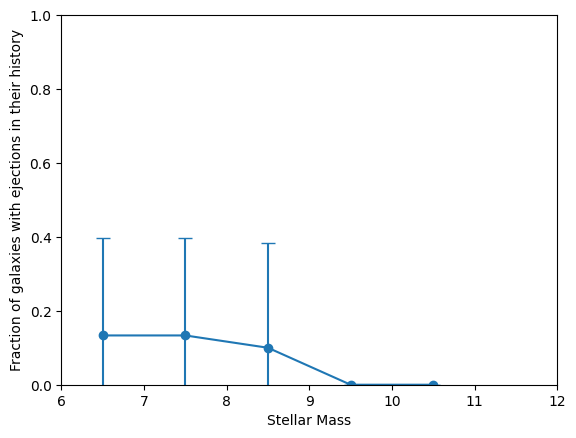

In [387]:
## EJECTION FRACTION PLOT WITH ERROR BARS
def safe_div(numerator, denominator):
        if denominator > 0:
            return numerator / denominator
        else:
            return 0.0

eject_mask = (galaxies.StellarMass > 0) & (galaxies.BHejectCount > 0)
stellar_mass = galaxies.StellarMass
stellar_mass_eject = galaxies.StellarMass[eject_mask]


min_range = 6
max_range = 12
interval = 1
nbins = int((max_range - min_range) / interval)
mass_bins = np.arange(min_range, max_range, interval)


mass = []  # Bin centers
bh_eject_fraction = []
errors = []
for i in range(nbins - 1):
        # All galaxies in this mass bin
        this_bin_mask = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i + 1])
        this_bin_count = np.sum(this_bin_mask)

        # Galaxies that have had ejected black holes in this mass been
        bh_eject_mask = (stellar_mass_eject >= mass_bins[i]) & (stellar_mass_eject < mass_bins[i + 1])
        bh_eject_count = np.sum(bh_eject_mask)

        #Calculate occupation fraction
        bh_eject_fraction.append(safe_div(bh_eject_count, this_bin_count))

        # Standard deviation (binomial) for ejection fraction
        bh_eject_frac = safe_div(bh_eject_count, this_bin_count)
        sigma = np.sqrt(safe_div(bh_eject_frac*(1-bh_eject_frac), this_bin_count))
        errors.append(3*sigma)
        

        # Store the mass bin center
        mass.append((mass_bins[i] + mass_bins[i + 1]) / 2.0)

plt.errorbar(mass, bh_eject_fraction, marker='o', yerr=errors, capsize=5)
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of galaxies with ejections in their history')
plt.xlim(min_range, max_range)
plt.ylim(0, 1)